In [147]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, filtfilt
from scipy.signal import spectrogram, kaiser



# Simulate the data

In [148]:
#stałe
n = 6
A = 10
a = 0.75
fs = 16384
T = 2.5
f = 190
sigma = 0.1

t = np.linspace(0,T,int(fs*T), endpoint = False)
N = 3000

# Funkcje

In [149]:
def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low,high],btype = 'band')
    return lfilter(b,a,data)

def bandstop_filter(signal, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandstop')
    return filtfilt(b, a, signal)

def faulty(t, fs, noise):
    
    # przepuścić szum przez filtr pasmowy (1000 - 6000 Hz)
    noise_band = bandpass_filter(noise, fs, 1000, 6000)
    noise_other = bandstop_filter(noise, fs, 1000, 6000)

    # Wygenerować sygnał impulsowy z częstotliwością 13Hz
    f_fault = 13
    n_harm = 6 #zmienimy potem na 6
    impulse_train = np.zeros_like(t)
    for k in range(1, n_harm + 1):
        impulse_train += np.sin(2* np.pi *f_fault*k*t)
    
    # Normalizacja impulsów
    impulse_train = impulse_train / np.max(np.abs(impulse_train))

    noise_faulty = noise_other + noise_band*(1 + impulse_train)

    return noise_faulty

def X(t,n,A,a,f,sigma, noise):
    x = np.zeros_like(t)
    for i in range(1,n+1):
        x += A*np.power(a,i-1)*np.sin(2*np.pi*f*i*t)
    x += sigma*noise
    return x

## Szumy

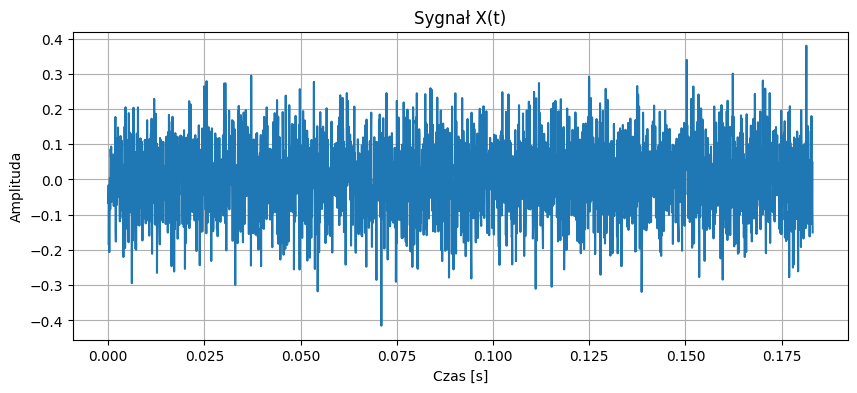

In [150]:
noise = sigma* np.random.normal(0,1,len(t))
# wykres
plt.figure(figsize=(10,4))
plt.plot(t[:N], noise[:N])  # pokażmy tylko kawałek
plt.title("Sygnał X(t)")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.grid(True)
plt.show()

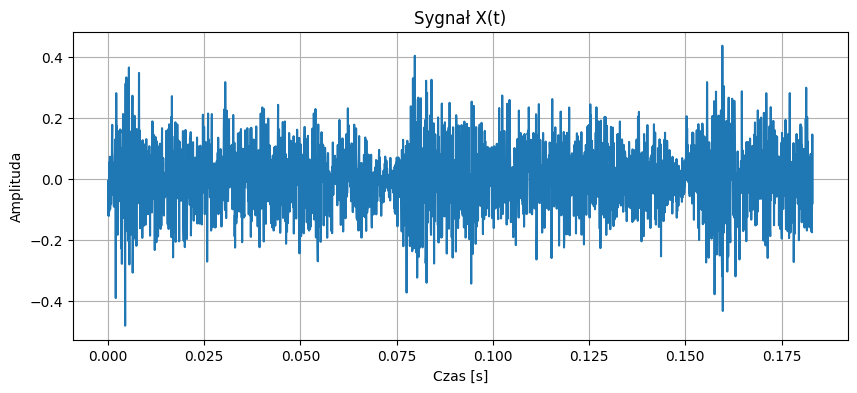

In [151]:
noisefaulty = faulty(t, fs, noise)
# wykres
plt.figure(figsize=(10,4))
plt.plot(t[:N], noisefaulty[:N])  # pokażmy tylko kawałek
plt.title("Sygnał X(t)")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.grid(True)
plt.show()

## Healthy signal

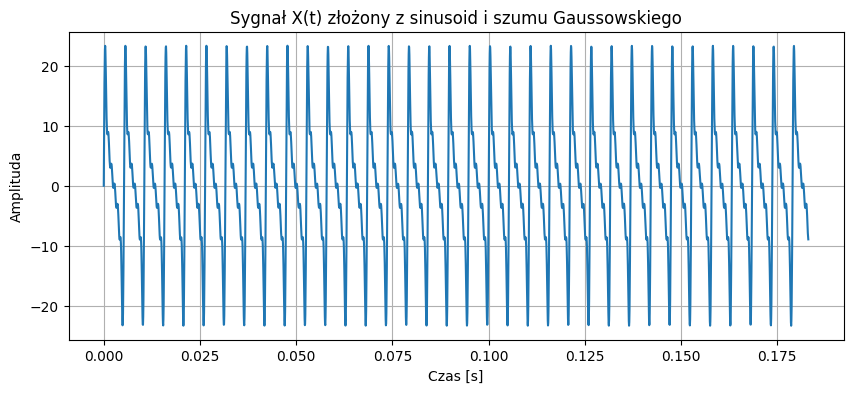

In [152]:
signal = X(t,n,A,a,f,sigma,noise)
# Rysunek
plt.figure(figsize=(10, 4))
plt.plot(t[:N], signal[:N])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Sygnał X(t) złożony z sinusoid i szumu Gaussowskiego")
plt.grid(True)
plt.show()


## Faulty signal

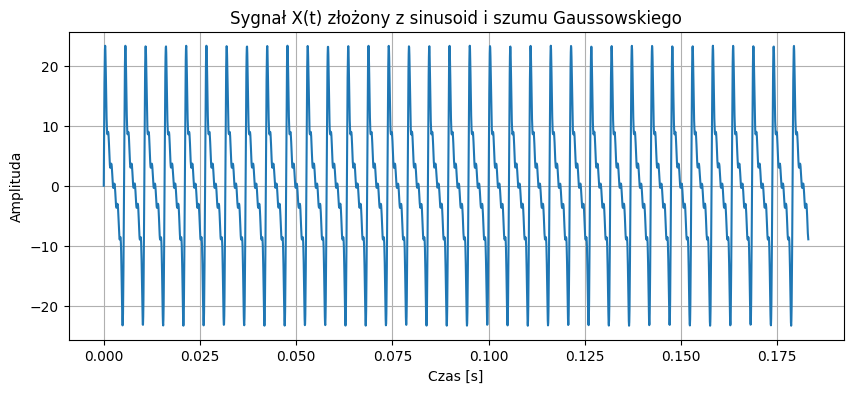

In [153]:
signal_faulty = X(t,n,A,a,f,sigma,noisefaulty)

# Rysunek
plt.figure(figsize=(10, 4))
plt.plot(t[:N], signal_faulty[:N])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Sygnał X(t) złożony z sinusoid i szumu Gaussowskiego")
plt.grid(True)
plt.show()

# Wizualizacje

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15368\771348212.py:4: DeprecationWarning: Importing kaiser from 'scipy.signal' is deprecated since SciPy 1.1.0 and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.kaiser' or the convenience function 'scipy.signal.get_window' instead.
  window = kaiser(219, beta=14)  # beta kontroluje kształt okna


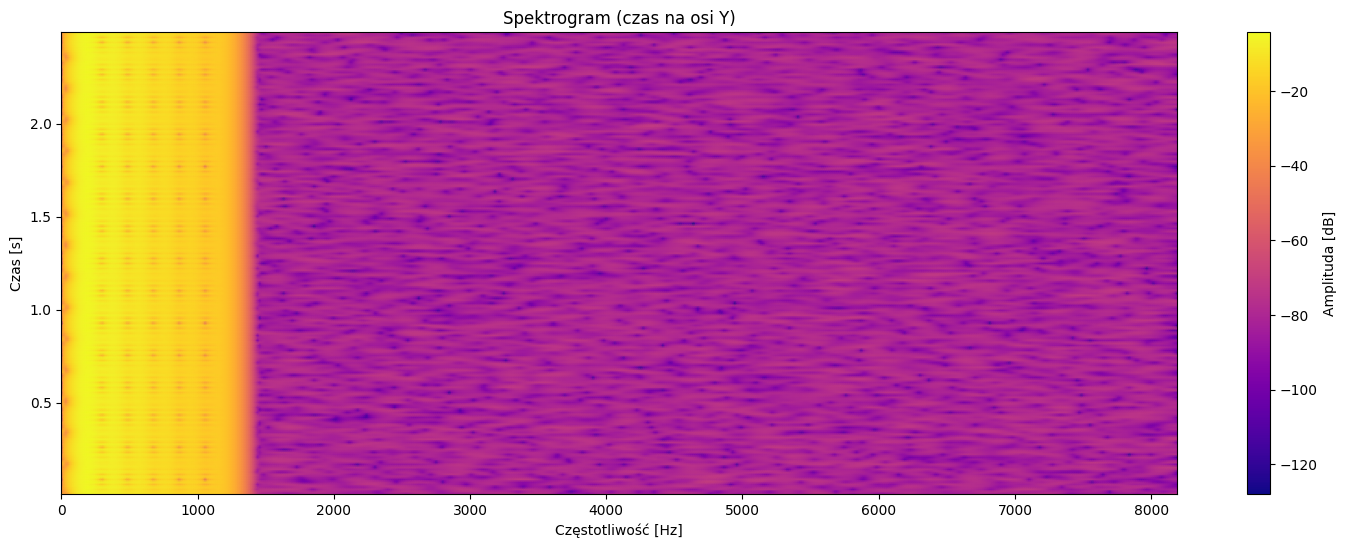

In [154]:
nfft = 1024
noverlap = 0
nperseg = 219
window = kaiser(219, beta=14)  # beta kontroluje kształt okna

f, tt, Sxx = spectrogram(signal,fs=fs,window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
plt.figure(figsize=(18, 6))
plt.pcolormesh(f, tt, 10*np.log10(Sxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram (czas na osi Y)')
plt.colorbar(label='Amplituda [dB]')
plt.show()

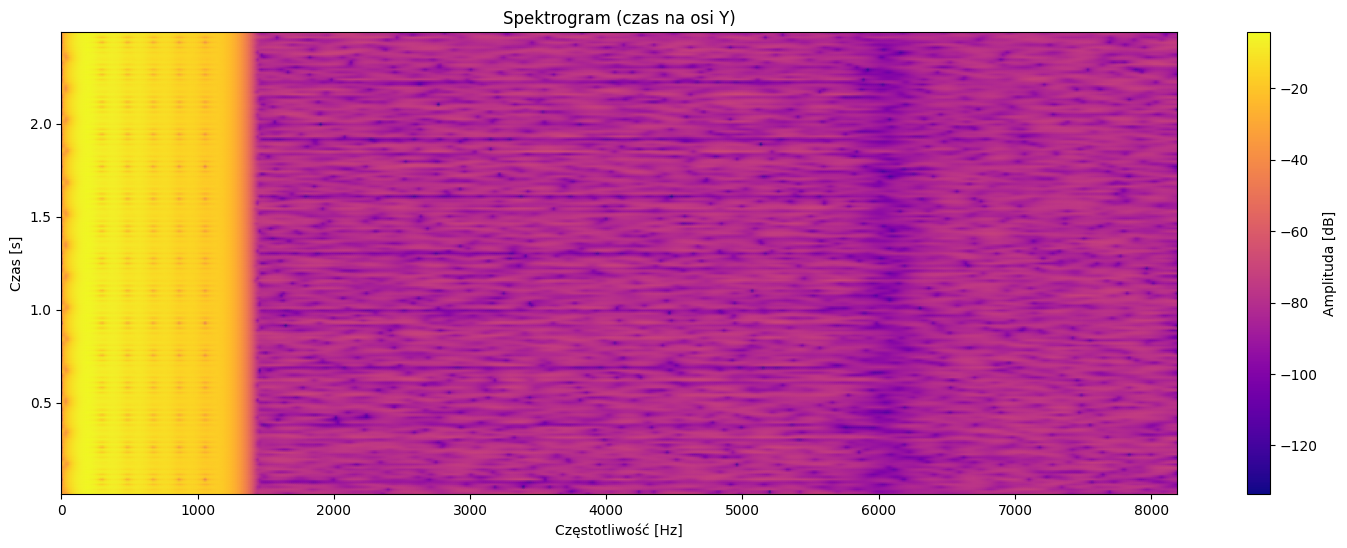

In [155]:
f, tt, Sxx = spectrogram(signal_faulty,fs=fs,window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)

plt.figure(figsize=(18, 6))
plt.pcolormesh(f, tt, 10*np.log10(Sxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram (czas na osi Y)')
plt.colorbar(label='Amplituda [dB]')
plt.show()